# Importing Libraries

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading the Files

In [11]:
weather = pd.read_csv('C:/Users/ithil/Desktop/projects/python projects/energydemand/weather.csv')
electric = pd.read_csv('C:/Users/ithil/Desktop/projects/python projects/energydemand/electric_usage.csv', encoding='utf-8-sig')
print("weather:",weather.shape)
print("electric:",electric.shape)

weather: (4069, 44)
electric: (52535, 8)


## Parse Dates

In [17]:
electric.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52535 entries, 0 to 52534
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TYPE        52535 non-null  object 
 1   DATE        52535 non-null  object 
 2   START TIME  52535 non-null  object 
 3   END TIME    52535 non-null  object 
 4   USAGE       52535 non-null  float64
 5   UNITS       52535 non-null  object 
 6   COST        52535 non-null  object 
 7   NOTES       25 non-null     object 
dtypes: float64(1), object(7)
memory usage: 3.2+ MB


In [23]:
# combining date and timestamp for electric 
weather['DATE'] = pd.to_datetime(weather['DATE'])
electric['DATE'] = pd.to_datetime(electric['DATE'])
electric['TIMESTAMP'] = pd.to_datetime(
    electric['DATE'].astype(str) + ' ' + electric['START TIME'])
print(weather['DATE'].dtype,  electric['TIMESTAMP'].dtype)


datetime64[ns] datetime64[ns]


## Cleaning weather data


In [24]:
# keeping only the date,percipitation and three temperature fileds
weather = weather[weather['STATION'] == 'USW00023257']

weather_clean = weather[['DATE', 'PRCP', 'TMAX', 'TMIN', 'TAVG']].copy()
weather_clean.head()

,DATE,PRCP,TMAX,TMIN,TAVG
1870,2014-07-01,0.0,103.0,69.0,NaN
1871,2014-07-02,0.0,100.0,65.0,NaN
1872,2014-07-03,0.0,101.0,65.0,NaN
1873,2014-07-04,0.0,105.0,62.0,NaN
1874,2014-07-05,0.0,102.0,67.0,NaN


## Checking for missing Values

In [26]:
print("Weather missing values:")
print(weather_clean.isna().sum())
print()
print("Electric missing values:")
print(electric[['USAGE', 'COST']].isna().sum())
print()


Weather missing values:
DATE       0
PRCP       4
TMAX       5
TMIN       7
TAVG    2199
dtype: int64

Electric missing values:
USAGE    0
COST     0
dtype: int64



In [27]:
print("Weather:", weather_clean['DATE'].min(), "to", weather_clean['DATE'].max())
print("Electric:", electric['DATE'].min(), "to", electric['DATE'].max())


Weather: 2014-07-01 00:00:00 to 2020-07-07 00:00:00
Electric: 2014-09-01 00:00:00 to 2020-09-30 00:00:00


## Aggregating day wise electric usage

In [28]:
electric['COST'] = electric['COST'].replace(r'[\$,]', '', regex=True).astype(float)

electric_daily = electric.groupby('DATE').agg(
    USAGE_KWH=('USAGE', 'sum'),
    COST=('COST', 'sum'),
    HOURS_RECORDED=('USAGE', 'count')
).reset_index()

print(electric_daily.shape)
electric_daily.head()


(2189, 4)


,DATE,USAGE_KWH,COST,HOURS_RECORDED
0,2014-09-01,2.24,0.28,24
1,2014-09-02,2.09,0.27,24
2,2014-09-03,2.05,0.26,24
3,2014-09-04,2.03,0.25,24
4,2014-09-05,2.19,0.28,24


In [32]:
electric_daily[electric_daily['HOURS_RECORDED'] < 24]

,DATE,USAGE_KWH,COST,HOURS_RECORDED
188,2015-03-08,6.95,1.15,23
559,2016-03-13,11.40,2.09,23
890,2017-03-12,5.14,1.02,23
1254,2018-03-11,21.12,4.47,23
1618,2019-03-10,12.60,2.76,23
1982,2020-03-08,5.07,1.19,23


## Data Quality Check

In [33]:
incomplete_days = electric_daily[electric_daily['HOURS_RECORDED'] < 24]
print(f"{len(incomplete_days)} incomplete days out of {len(electric_daily)} total")
incomplete_days.head()

6 incomplete days out of 2189 total


,DATE,USAGE_KWH,COST,HOURS_RECORDED
188,2015-03-08,6.95,1.15,23
559,2016-03-13,11.40,2.09,23
890,2017-03-12,5.14,1.02,23
1254,2018-03-11,21.12,4.47,23
1618,2019-03-10,12.60,2.76,23


##  Combining Usage and weather data

In [36]:
daily = electric_daily.merge(weather_clean, on='DATE', how='inner')

print("Joined dataset:", daily.shape)
daily.head()

Joined dataset: (2104, 8)


,DATE,USAGE_KWH,COST,HOURS_RECORDED,PRCP,TMAX,TMIN,TAVG
0,2014-09-01,2.24,0.28,24,0.0,98.0,62.0,NaN
1,2014-09-02,2.09,0.27,24,0.0,101.0,64.0,NaN
2,2014-09-03,2.05,0.26,24,0.0,93.0,62.0,NaN
3,2014-09-04,2.03,0.25,24,0.0,96.0,62.0,NaN
4,2014-09-05,2.19,0.28,24,0.0,94.0,61.0,NaN


In [37]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2104 entries, 0 to 2103
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATE            2104 non-null   datetime64[ns]
 1   USAGE_KWH       2104 non-null   float64       
 2   COST            2104 non-null   float64       
 3   HOURS_RECORDED  2104 non-null   int64         
 4   PRCP            2100 non-null   float64       
 5   TMAX            2099 non-null   float64       
 6   TMIN            2097 non-null   float64       
 7   TAVG            0 non-null      float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 131.6 KB


In [38]:
df = daily.copy()

df = df.sort_values("DATE").reset_index(drop=True)

# Remove completely empty column
df = df.drop(columns=["TAVG"])

# Derived average temperature
df["TEMP_AVG"] = (df["TMAX"] + df["TMIN"]) / 2

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2104 entries, 0 to 2103
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATE            2104 non-null   datetime64[ns]
 1   USAGE_KWH       2104 non-null   float64       
 2   COST            2104 non-null   float64       
 3   HOURS_RECORDED  2104 non-null   int64         
 4   PRCP            2100 non-null   float64       
 5   TMAX            2099 non-null   float64       
 6   TMIN            2097 non-null   float64       
 7   TEMP_AVG        2096 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 131.6 KB


In [39]:
df.isnull().sum()

DATE              0
USAGE_KWH         0
COST              0
HOURS_RECORDED    0
PRCP              4
TMAX              5
TMIN              7
TEMP_AVG          8
dtype: int64

In [40]:
df[df[["PRCP", "TMAX", "TMIN"]].isna().any(axis=1)]

,DATE,USAGE_KWH,COST,HOURS_RECORDED,PRCP,TMAX,TMIN,TEMP_AVG
149,2015-01-28,1.57,0.24,24,0.00,NaN,NaN,NaN
150,2015-01-29,1.84,0.32,24,0.00,59.0,NaN,NaN
181,2015-03-01,4.41,0.72,24,0.00,NaN,NaN,NaN
182,2015-03-02,2.81,0.44,24,0.08,NaN,NaN,NaN
330,2015-07-28,15.94,4.71,24,0.00,99.0,NaN,NaN
416,2015-10-22,4.89,0.80,24,0.00,83.0,NaN,NaN
554,2016-03-08,2.79,0.51,24,0.00,NaN,NaN,NaN
1280,2018-04-06,3.99,0.84,24,NaN,64.0,59.0,61.5
1509,2018-11-21,5.44,1.18,24,NaN,68.0,37.0,52.5
1517,2018-11-29,5.93,1.26,24,0.47,NaN,53.0,NaN


In [41]:
# Filling missing values with inetrpolation
df["TMAX"] = df["TMAX"].interpolate()
df["TMIN"] = df["TMIN"].interpolate()

df["TEMP_AVG"] = (df["TMAX"] + df["TMIN"]) / 2

## Exploratory data Analysis

In [42]:
df["USAGE_KWH"].describe()

count    2104.000000
mean       13.127058
std        14.394357
min         0.000000
25%         4.140000
50%         7.530000
75%        16.172500
max        94.250000
Name: USAGE_KWH, dtype: float64

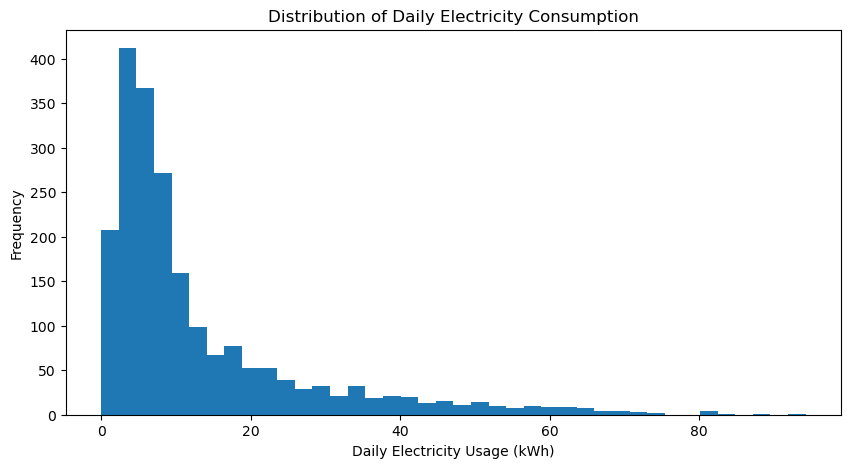

In [44]:
# Histogram of usage
plt.figure(figsize=(10,5))
plt.hist(df["USAGE_KWH"], bins=40)
plt.xlabel("Daily Electricity Usage (kWh)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Electricity Consumption")
plt.show()

In [ ]:
#strongly right-skewed distribution/positively skewed.Most days appear to have relatively low consumption, roughly concentrated around 2–12 kWh, while a smaller number of days have much higher consumption—20, 40, 60, and even around 90 kWh.

## Daily Analysis

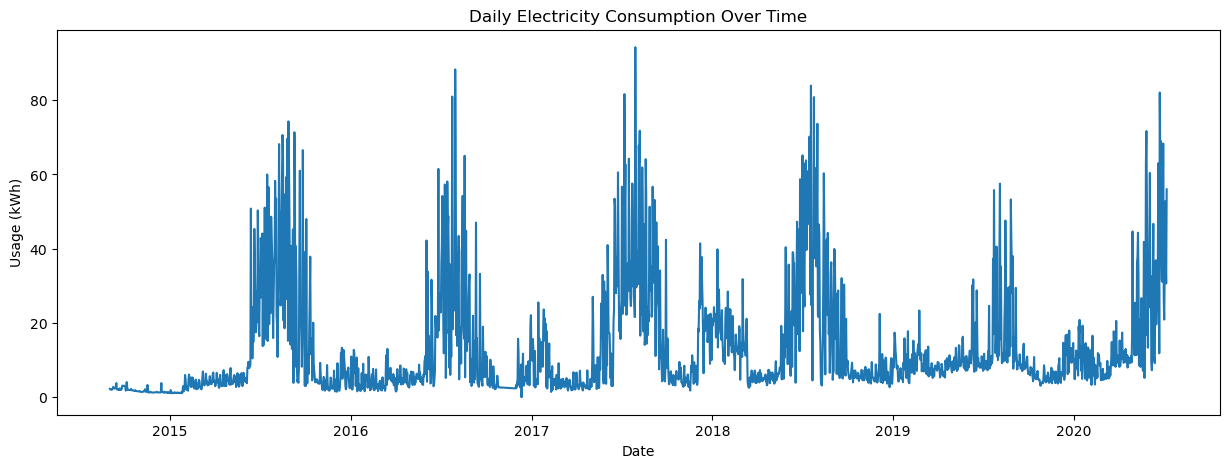

In [45]:
plt.figure(figsize=(15,5))
plt.plot(df["DATE"], df["USAGE_KWH"])
plt.xlabel("Date")
plt.ylabel("Usage (kWh)")
plt.title("Daily Electricity Consumption Over Time")
plt.show()

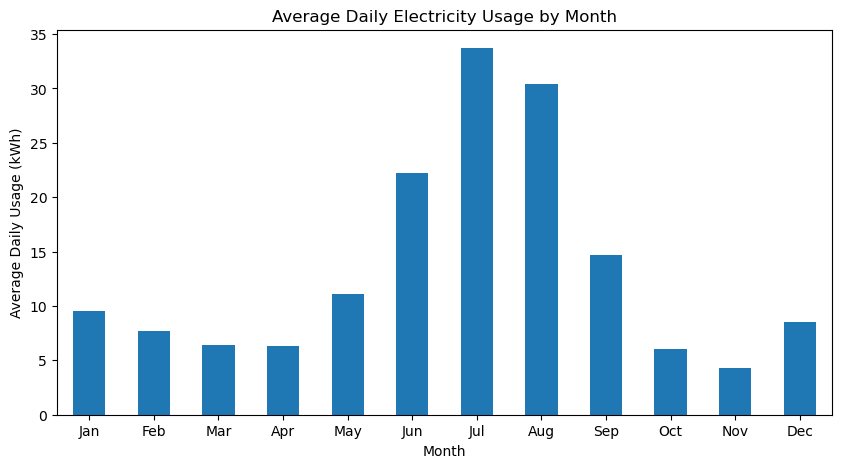

In [46]:
df["MONTH"] = df["DATE"].dt.month

monthly_avg = (
    df.groupby("MONTH")["USAGE_KWH"]
      .mean()
)

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Average Daily Usage (kWh)")
plt.title("Average Daily Electricity Usage by Month")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)
plt.show()

## Temperature Analysis

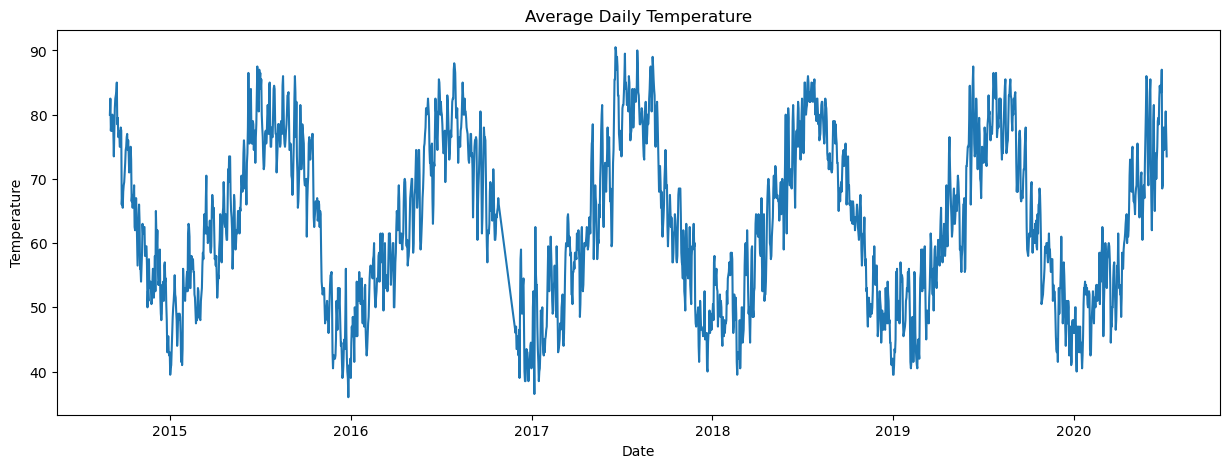

In [48]:
plt.figure(figsize=(15,5))
plt.plot(df["DATE"], df["TEMP_AVG"])
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Average Daily Temperature")
plt.show()

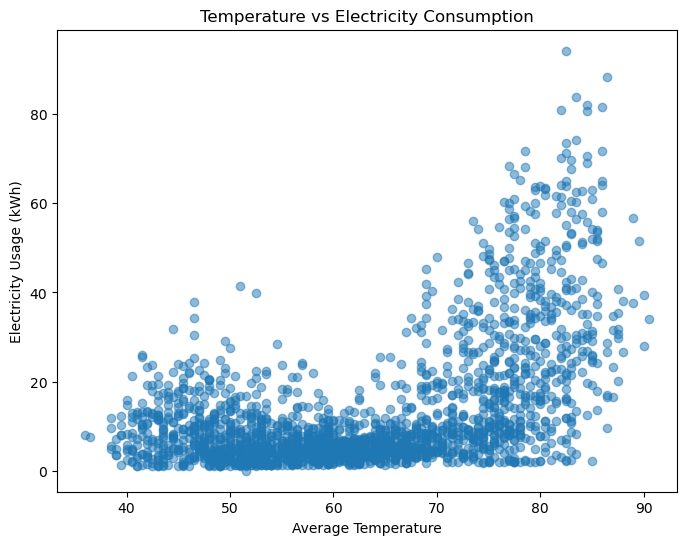

In [49]:
# Electicity Usage Vs temperature
plt.figure(figsize=(8,6))
plt.scatter(df["TEMP_AVG"], df["USAGE_KWH"], alpha=0.5)
plt.xlabel("Average Temperature")
plt.ylabel("Electricity Usage (kWh)")
plt.title("Temperature vs Electricity Consumption")
plt.show()

In [ ]:
#High temperatures may cause higher electricity demand because of air-conditioning.Non-linear relationship

## Correlation

In [50]:
df[
    ["USAGE_KWH", "COST", "PRCP",
     "TMAX", "TMIN", "TEMP_AVG"]
].corr()

,USAGE_KWH,COST,PRCP,TMAX,TMIN,TEMP_AVG
USAGE_KWH,1.000000,0.967327,-0.111626,0.514335,0.498811,0.528295
COST,0.967327,1.000000,-0.107656,0.492865,0.477162,0.505893
PRCP,-0.111626,-0.107656,1.000000,-0.250344,-0.045293,-0.173427
TMAX,0.514335,0.492865,-0.250344,1.000000,0.844010,0.973847
TMIN,0.498811,0.477162,-0.045293,0.844010,1.000000,0.943792
TEMP_AVG,0.528295,0.505893,-0.173427,0.973847,0.943792,1.000000


In [ ]:
# cost and usage has positive corelation .

## FEATURE ENGINEERING

In [51]:
df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["DAY_OF_WEEK"] = df["DATE"].dt.dayofweek
df["DAY_OF_YEAR"] = df["DATE"].dt.dayofyear

df["WEEKEND"] = (
    df["DAY_OF_WEEK"] >= 5
).astype(int)

In [52]:
# season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["SEASON"] = df["MONTH"].apply(get_season)

In [53]:
df.groupby("SEASON")["USAGE_KWH"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
SEASON,,,
Fall,8.564133,5.170,10.476699
Spring,7.924420,5.925,7.539739
Summer,28.530443,24.620,18.440380
Winter,8.619963,6.890,6.797772


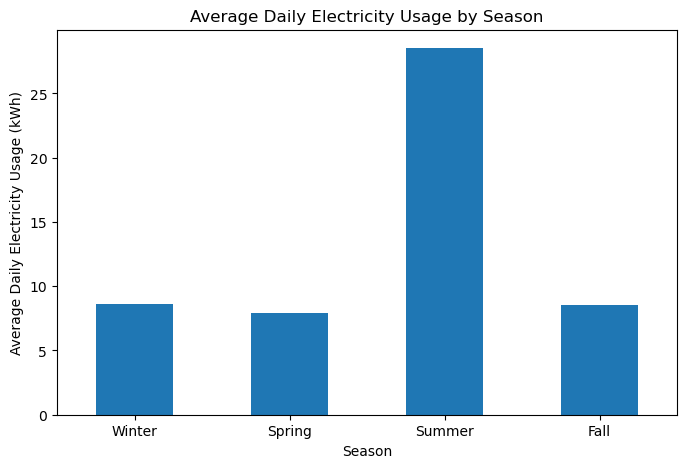

In [55]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_avg = (
    df.groupby("SEASON")["USAGE_KWH"]
      .mean()
      .reindex(["Winter", "Spring", "Summer", "Fall"])
)

plt.figure(figsize=(8, 5))

season_avg.plot(kind="bar")

plt.xlabel("Season")
plt.ylabel("Average Daily Electricity Usage (kWh)")
plt.title("Average Daily Electricity Usage by Season")
plt.xticks(rotation=0)

plt.show()

In [56]:
# Sort the table
df = df.sort_values("DATE").reset_index(drop=True)
df[["DATE", "USAGE_KWH"]].head()

,DATE,USAGE_KWH
0,2014-09-01,2.24
1,2014-09-02,2.09
2,2014-09-03,2.05
3,2014-09-04,2.03
4,2014-09-05,2.19


## Model 1: Naive forecast

In [58]:
df["NAIVE_1DAY"] = df["USAGE_KWH"].shift(1)
df[["DATE", "USAGE_KWH", "NAIVE_1DAY"]].head(10)

,DATE,USAGE_KWH,NAIVE_1DAY
0,2014-09-01,2.24,NaN
1,2014-09-02,2.09,2.24
2,2014-09-03,2.05,2.09
3,2014-09-04,2.03,2.05
4,2014-09-05,2.19,2.03
5,2014-09-06,2.10,2.19
6,2014-09-07,2.41,2.10
7,2014-09-08,2.83,2.41
8,2014-09-09,2.57,2.83
9,2014-09-10,2.35,2.57


In [59]:
# train/Test data
split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Training period:")
print(train["DATE"].min(), "to", train["DATE"].max())

print("\nTest period:")
print(test["DATE"].min(), "to", test["DATE"].max())

Training period:
2014-09-01 00:00:00 to 2019-05-13 00:00:00

Test period:
2019-05-14 00:00:00 to 2020-07-07 00:00:00


In [60]:
test_naive = test.dropna(subset=["NAIVE_1DAY"]).copy()
# Forecast errors
test_naive["ERROR"] = (test_naive["USAGE_KWH"]- test_naive["NAIVE_1DAY"])
test_naive["ABS_ERROR"] = abs(test_naive["ERROR"])
test_naive[["DATE", "USAGE_KWH", "NAIVE_1DAY", "ERROR", "ABS_ERROR"]].head(10)

,DATE,USAGE_KWH,NAIVE_1DAY,ERROR,ABS_ERROR
1683,2019-05-14,14.01,9.40,4.61,4.61
1684,2019-05-15,13.84,14.01,-0.17,0.17
1685,2019-05-16,8.31,13.84,-5.53,5.53
1686,2019-05-17,8.64,8.31,0.33,0.33
1687,2019-05-18,8.54,8.64,-0.10,0.10
1688,2019-05-19,10.03,8.54,1.49,1.49
1689,2019-05-20,9.55,10.03,-0.48,0.48
1690,2019-05-21,15.78,9.55,6.23,6.23
1691,2019-05-22,16.29,15.78,0.51,0.51
1692,2019-05-23,10.26,16.29,-6.03,6.03


In [83]:
#  Mean absolute error(MAE)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test_naive["USAGE_KWH"],test_naive["NAIVE_1DAY"])
print("Naive MAE:", mae)

Naive MAE: 6.363016627078385


In [ ]:
#The naive forecast differs from actual daily electricity consumption by approximately 6.4 kWh per day on average.

In [63]:
#  Root Mean squared error(RMSE)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_naive["USAGE_KWH"],test_naive["NAIVE_1DAY"]))
print("Naive RMSE:", rmse)

Naive RMSE: 10.960286473101265


In [ ]:
# RMSE >MSE

In [65]:
#  Weighted Absolute percentage error
wape = (test_naive["ABS_ERROR"].sum()/ test_naive["USAGE_KWH"].sum()) * 100
print("Naive WAPE:", wape, "%")

Naive WAPE: 44.452612399730526 %


In [66]:
# calculate Forecast Bias
bias = (test_naive["ERROR"].sum()/ test_naive["USAGE_KWH"].sum()) * 100
print("Forecast Bias:", bias, "%")

Forecast Bias: 0.7731163275398015 %


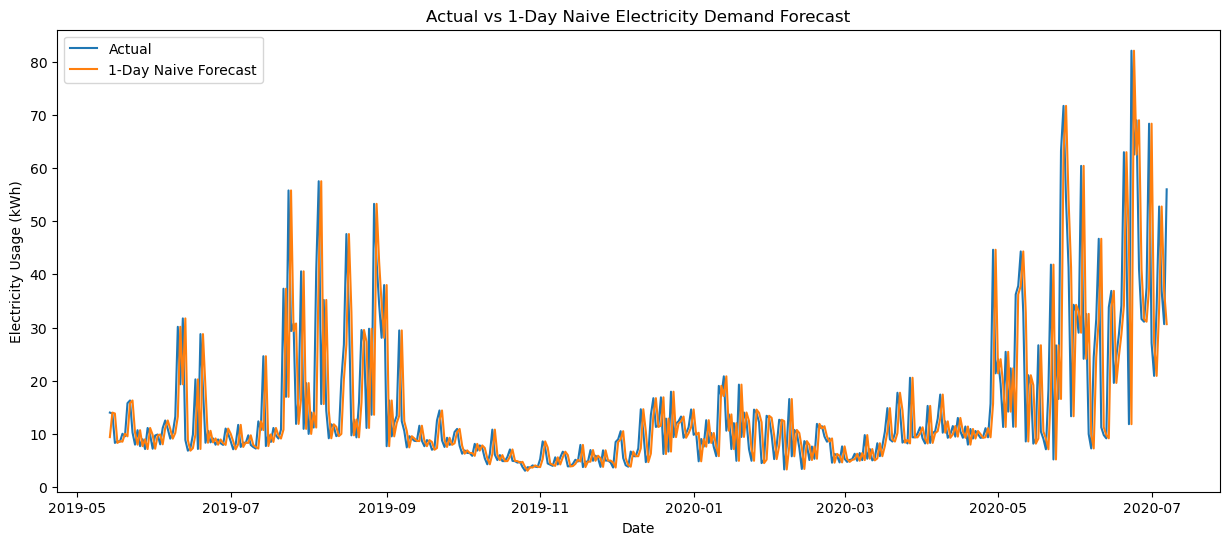

In [88]:
# actual forecast Vs Naive forecast
plot_data = test_naive.head(90)
plt.figure(figsize=(15, 6))

plt.plot(test_naive["DATE"],test_naive["USAGE_KWH"],label="Actual")
plt.plot(test_naive["DATE"],test_naive["NAIVE_1DAY"],label="1-Day Naive Forecast")

plt.xlabel("Date")
plt.ylabel("Electricity Usage (kWh)")
plt.title("Actual vs 1-Day Naive Electricity Demand Forecast")
plt.legend()

plt.show()

In [69]:
# results
naive_results = {"Model": "1-Day Naive","MAE": mae,"RMSE": rmse,"WAPE": wape,"Bias": bias}
print(naive_results)

{'Model': '1-Day Naive', 'MAE': 6.363016627078385, 'RMSE': 10.960286473101265, 'WAPE': 44.452612399730526, 'Bias': 0.7731163275398015}


## Model2: 7-day Seasonal Naive

In [73]:
# data sorted
df = df.sort_values("DATE").reset_index(drop=True)
df[["DATE", "USAGE_KWH"]].head(10)

,DATE,USAGE_KWH
0,2014-09-01,2.24
1,2014-09-02,2.09
2,2014-09-03,2.05
3,2014-09-04,2.03
4,2014-09-05,2.19
5,2014-09-06,2.10
6,2014-09-07,2.41
7,2014-09-08,2.83
8,2014-09-09,2.57
9,2014-09-10,2.35


In [76]:
# 7-day Seasonal Naive
df["NAIVE_7DAY"] = df["USAGE_KWH"].shift(7)
df[["DATE", "USAGE_KWH", "NAIVE_7DAY"]].head(12)

,DATE,USAGE_KWH,NAIVE_7DAY
0,2014-09-01,2.24,NaN
1,2014-09-02,2.09,NaN
2,2014-09-03,2.05,NaN
3,2014-09-04,2.03,NaN
4,2014-09-05,2.19,NaN
5,2014-09-06,2.10,NaN
6,2014-09-07,2.41,NaN
7,2014-09-08,2.83,2.24
8,2014-09-09,2.57,2.09
9,2014-09-10,2.35,2.05


In [77]:
split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

In [78]:
test_seasonal = test.dropna(subset=["NAIVE_7DAY"]).copy()
test_seasonal["ERROR"] = (test_seasonal["USAGE_KWH"]- test_seasonal["NAIVE_7DAY"])
# absolute error
test_seasonal["ABS_ERROR"] = (test_seasonal["ERROR"].abs())
test_seasonal[[ "DATE","USAGE_KWH","NAIVE_7DAY","ERROR","ABS_ERROR"]].head(10)

,DATE,USAGE_KWH,NAIVE_7DAY,ERROR,ABS_ERROR
1683,2019-05-14,14.01,9.20,4.81,4.81
1684,2019-05-15,13.84,13.29,0.55,0.55
1685,2019-05-16,8.31,8.24,0.07,0.07
1686,2019-05-17,8.64,7.06,1.58,1.58
1687,2019-05-18,8.54,7.34,1.20,1.20
1688,2019-05-19,10.03,7.43,2.60,2.60
1689,2019-05-20,9.55,9.40,0.15,0.15
1690,2019-05-21,15.78,14.01,1.77,1.77
1691,2019-05-22,16.29,13.84,2.45,2.45
1692,2019-05-23,10.26,8.31,1.95,1.95


In [81]:
#MAE
mae_7day = mean_absolute_error(test_seasonal["USAGE_KWH"],test_seasonal["NAIVE_7DAY"])
print(f"7-Day Naive MAE: {mae_7day:.2f}")

7-Day Naive MAE: 7.29


In [82]:
# RMSE
rmse_7day = np.sqrt(mean_squared_error(test_seasonal["USAGE_KWH"],test_seasonal["NAIVE_7DAY"]))
print(f"7-Day Naive RMSE: {rmse_7day:.2f}")

7-Day Naive RMSE: 12.80


In [84]:
# WAPE
wape_7day = (test_seasonal["ABS_ERROR"].sum() / test_seasonal["USAGE_KWH"].sum()) * 100
print(f"7-Day Naive WAPE: {wape_7day:.2f}%")

7-Day Naive WAPE: 50.91%


In [85]:
# Forecast bias
bias_7day = (test_seasonal["ERROR"].sum()/ test_seasonal["USAGE_KWH"].sum()) * 100
print(f"7-Day Naive Bias: {bias_7day:.2f}%")

7-Day Naive Bias: 3.25%


In [87]:
Naive_7_day_results = {"Model": "7-Day Naive","MAE": mae_7day,"RMSE": rmse_7day,"WAPE": wape_7day,"Bias": bias_7day}
print(Naive_7_day_results)

{'Model': '7-Day Naive', 'MAE': 7.286840855106889, 'RMSE': 12.804882178331438, 'WAPE': 50.906532409819704, 'Bias': 3.251436214169319}


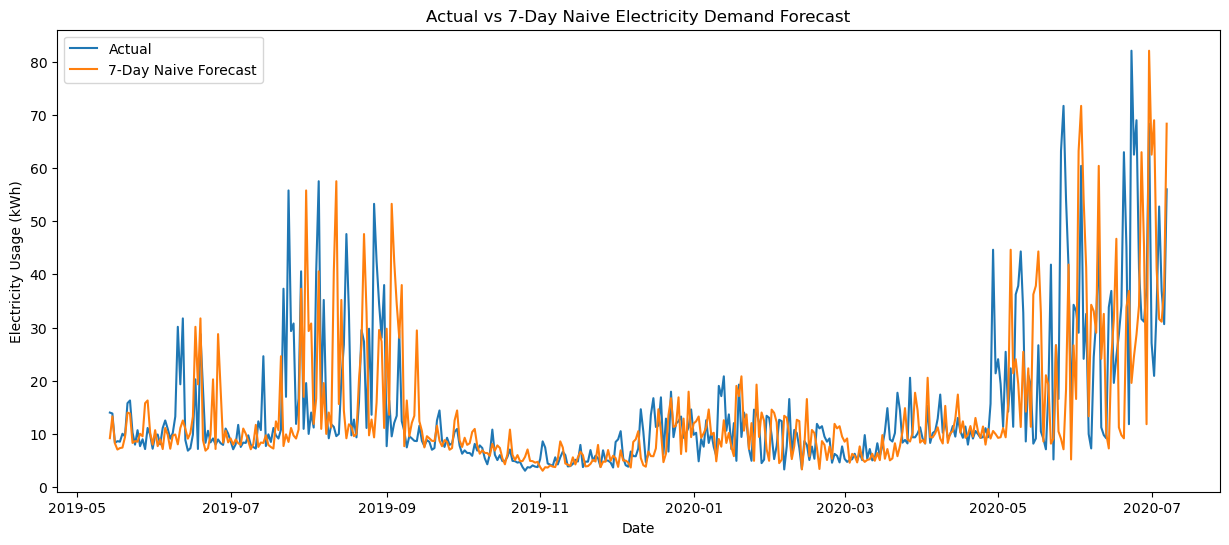

In [89]:
# actual forecast Vs Naive 7 day forecast

plt.figure(figsize=(15, 6))

plt.plot(test_seasonal["DATE"],test_seasonal["USAGE_KWH"],label="Actual")
plt.plot(test_seasonal["DATE"],test_seasonal["NAIVE_7DAY"],label="7-Day Naive Forecast")

plt.xlabel("Date")
plt.ylabel("Electricity Usage (kWh)")
plt.title("Actual vs 7-Day Naive Electricity Demand Forecast")
plt.legend()

plt.show()

In [90]:
df.head(10)


,DATE,USAGE_KWH,COST,HOURS_RECORDED,PRCP,TMAX,TMIN,TEMP_AVG,MONTH,YEAR,DAY_OF_WEEK,DAY_OF_YEAR,WEEKEND,SEASON,NAIVE_1DAY,NAIVE_7DAY
0,2014-09-01,2.24,0.28,24,0.0,98.0,62.0,80.0,9,2014,0,244,0,Fall,NaN,NaN
1,2014-09-02,2.09,0.27,24,0.0,101.0,64.0,82.5,9,2014,1,245,0,Fall,2.24,NaN
2,2014-09-03,2.05,0.26,24,0.0,93.0,62.0,77.5,9,2014,2,246,0,Fall,2.09,NaN
3,2014-09-04,2.03,0.25,24,0.0,96.0,62.0,79.0,9,2014,3,247,0,Fall,2.05,NaN
4,2014-09-05,2.19,0.28,24,0.0,94.0,61.0,77.5,9,2014,4,248,0,Fall,2.03,NaN
5,2014-09-06,2.10,0.27,24,0.0,97.0,63.0,80.0,9,2014,5,249,1,Fall,2.19,NaN
6,2014-09-07,2.41,0.35,24,0.0,97.0,60.0,78.5,9,2014,6,250,1,Fall,2.10,NaN
7,2014-09-08,2.83,0.47,24,0.0,92.0,63.0,77.5,9,2014,0,251,0,Fall,2.41,2.24
8,2014-09-09,2.57,0.37,24,0.0,92.0,55.0,73.5,9,2014,1,252,0,Fall,2.83,2.09
9,2014-09-10,2.35,0.34,24,0.0,97.0,57.0,77.0,9,2014,2,253,0,Fall,2.57,2.05


## Model 3:Linear Regression

In [91]:
df = df.sort_values("DATE").reset_index(drop=True)

In [92]:
# lag variables
df["LAG_1"] = df["USAGE_KWH"].shift(1)

df["LAG_7"] = df["USAGE_KWH"].shift(7)

In [93]:
df.columns

Index(['DATE', 'USAGE_KWH', 'COST', 'HOURS_RECORDED', 'PRCP', 'TMAX', 'TMIN',
       'TEMP_AVG', 'MONTH', 'YEAR', 'DAY_OF_WEEK', 'DAY_OF_YEAR', 'WEEKEND',
       'SEASON', 'NAIVE_1DAY', 'NAIVE_7DAY', 'LAG_1', 'LAG_7'],
      dtype='object')

In [94]:
features=['USAGE_KWH','PRCP', 'TEMP_AVG','WEEKEND','LAG_1','LAG_7']

In [95]:
model_df = df.dropna(subset=features + ["USAGE_KWH"]).copy()

In [101]:
# split train and testing data
split_index = int(len(model_df) * 0.80)
train = model_df.iloc[:split_index].copy()
test = model_df.iloc[split_index:].copy()
print("Training period:")
print(train["DATE"].min(), "to", train["DATE"].max())

print("\nTest period:")
print(test["DATE"].min(), "to", test["DATE"].max())

Training period:
2014-09-08 00:00:00 to 2019-05-13 00:00:00

Test period:
2019-05-14 00:00:00 to 2020-07-07 00:00:00


In [102]:
# import statsmodel
import statsmodels.formula.api as smf
model = smf.ols(
    formula="USAGE_KWH ~ TEMP_AVG + PRCP + WEEKEND + LAG_1 + LAG_7", data=train).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              USAGE_KWH   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     498.8
Date:                Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:48:30   Log-Likelihood:                -6118.3
No. Observations:                1674   AIC:                         1.225e+04
Df Residuals:                    1668   BIC:                         1.228e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.1907      1.310     -7.780      0.0

In [ ]:
#The multiple linear regression model explains approximately 60% of the variation in daily electricity consumption. 
#Temperature, weekend status, previous-day demand, and previous-week demand are statistically significant predictors, 
# while precipitation is not statistically significant. Both short-term and weekly historical consumption patterns contribute strongly to current demand.

In [103]:
# predict
test["LINEAR_FORECAST"] = model.predict(test)

# Inspect
test[ ["DATE", "USAGE_KWH", "LINEAR_FORECAST"]].head()

,DATE,USAGE_KWH,LINEAR_FORECAST
1683,2019-05-14,14.01,10.576357
1684,2019-05-15,13.84,13.093367
1685,2019-05-16,8.31,9.784586
1686,2019-05-17,8.64,7.748100
1687,2019-05-18,8.54,10.010476


In [104]:
# calculate errors
test["ERROR"] = (test["USAGE_KWH"] - test["LINEAR_FORECAST"])
test["ABS_ERROR"] = test["ERROR"].abs()

In [105]:
# calculate MAE
mae_lr = mean_absolute_error(test["USAGE_KWH"],test["LINEAR_FORECAST"])
print(f"Linear Regression MAE: {mae_lr:.2f}")

Linear Regression MAE: 6.05


In [106]:
# calculate RMSE
rmse_lr = np.sqrt(mean_squared_error(test["USAGE_KWH"],test["LINEAR_FORECAST"]))
print(f"Linear Regression RMSE: {rmse_lr:.2f}")

Linear Regression RMSE: 9.58


In [107]:
#Calculate WAPE
wape_lr = (test["ABS_ERROR"].sum()/ test["USAGE_KWH"].sum()) * 100
print(f"Linear Regression WAPE: {wape_lr:.2f}%")

Linear Regression WAPE: 42.13%


In [108]:
#Calculate Bias
bias_lr = (test["ERROR"].sum()/ test["USAGE_KWH"].sum()) * 100
print(f"Linear Regression Bias: {bias_lr:.2f}%")

Linear Regression Bias: 1.73%


In [ ]:
#Bias- Positive → underforecasting

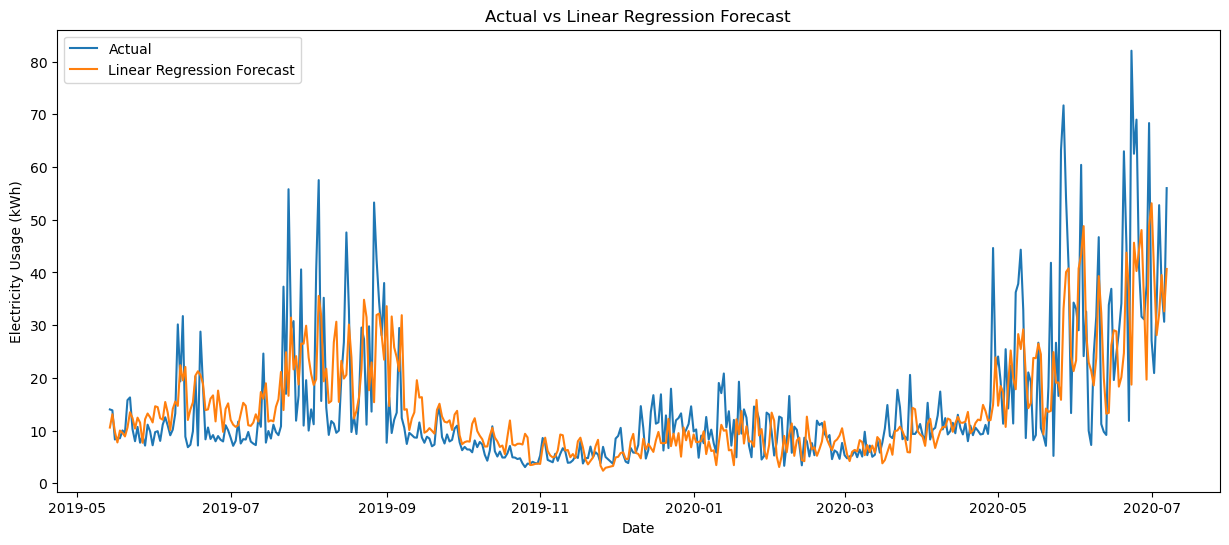

In [110]:
plt.figure(figsize=(15, 6))
plot_data = test

plt.plot(plot_data["DATE"],plot_data["USAGE_KWH"],label="Actual")

plt.plot(plot_data["DATE"],plot_data["LINEAR_FORECAST"],label="Linear Regression Forecast")

plt.xlabel("Date")
plt.ylabel("Electricity Usage (kWh)")
plt.title( "Actual vs Linear Regression Forecast")
plt.legend()
plt.show()

In [ ]:
# Linear regression captures the normal demaND PATTERN, but it systematically smoothing the extreme peaks.Seasonality is visible